# Notebook 04 — Test du modèle XGBoost LIAR sur Fake.csv / True.csv

**Dataset** : `data_set_random_01/` — Fake.csv + True.csv  
Toutes les colonnes sauf `label` sont concaténées en un seul champ texte.

**Modèle** : XGBoost pré-entraîné sur le LIAR dataset (`interface_web/model.pkl`)  
**TF-IDF** : vocabulaire LIAR (`interface_web/vectorizer.pkl`) — `.transform()` uniquement  
**Labels** : `0 = Fake`, `1 = True`  
**Évaluation** : Accuracy, F1-score, ROC-AUC, matrice de confusion.

## 0. Imports

In [23]:
import pickle
import re
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.sparse import hstack, csr_matrix

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)

nltk.download('stopwords', quiet=True)
nltk.download('wordnet', quiet=True)

ROOT      = Path("..").resolve()
DATA_DIR  = ROOT / "data_set_random_01"
IFACE_DIR = ROOT / "interface_web"

## 1. Chargement et mélange aléatoire

In [24]:
fake = pd.read_csv(DATA_DIR / "Fake.csv")
true = pd.read_csv(DATA_DIR / "True.csv")

fake["label"] = 0
true["label"] = 1

df = pd.concat([fake, true], ignore_index=True)
df = df.sample(frac=1, random_state=42).reset_index(drop=True)

# y utilisé pour l'entraînement, pas pour l'évaluation
y         = df["label"].values
text_cols = [c for c in df.columns if c != "label"]
print(f"Colonnes utilisées : {text_cols}")

for col in text_cols:
    df[col] = df[col].fillna("").astype(str)

X = df[text_cols].apply(lambda row: " ".join(row.values), axis=1)

print(f"\nDataset total : {len(df)} articles")
print(f"Fake (0) : {(y==0).sum()} | True (1) : {(y==1).sum()}")
print(f"\nExemple d'entrée (tronqué) :\n{X.iloc[0][:300]}")

Colonnes utilisées : ['title', 'text', 'subject', 'date']

Dataset total : 44898 articles
Fake (0) : 23481 | True (1) : 21417

Exemple d'entrée (tronqué) :
Ben Stein Calls Out 9th Circuit Court: Committed a ‘Coup d’état’ Against the Constitution 21st Century Wire says Ben Stein, reputable professor from, Pepperdine University (also of some Hollywood fame appearing in TV shows and films such as Ferris Bueller s Day Off) made some provocative statements 


## 1.5. Preprocessing — même pipeline que LIAR (lowercase, stopwords, lemmatisation)

In [25]:
_stop_words  = set(stopwords.words('english'))
_lemmatizer  = WordNetLemmatizer()

def preprocess(text: str) -> str:
    text   = text.lower()
    text   = re.sub(r'[^a-z\s]', ' ', text)
    tokens = [
        _lemmatizer.lemmatize(w)
        for w in text.split()
        if w not in _stop_words and len(w) > 2
    ]
    return ' '.join(tokens)

print("Preprocessing en cours...")
X = X.apply(preprocess)
print(f"Exemple préprocessé (tronqué) :\n{X.iloc[0][:300]}")

Preprocessing en cours...
Exemple préprocessé (tronqué) :
ben stein call circuit court committed coup tat constitution century wire say ben stein reputable professor pepperdine university also hollywood fame appearing show film ferris bueller day made provocative statement judge jeanine pirro show recently discussing halt imposed president trump executive 


## 2. Chargement du modèle LIAR + prédictions

Features TF-IDF : 14771

  Accuracy    : 0.4806
  F1 weighted : 0.3258
  ROC-AUC     : 0.5364
              precision    recall  f1-score   support

    Fake (0)       0.62      0.02      0.04     23481
    True (1)       0.48      0.99      0.64     21417

    accuracy                           0.48     44898
   macro avg       0.55      0.50      0.34     44898
weighted avg       0.55      0.48      0.33     44898



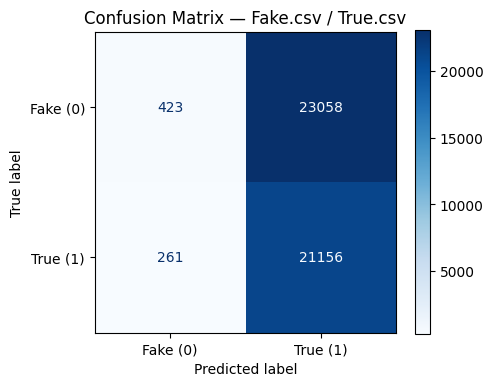

In [26]:
# --- Chargement du modèle pré-entraîné (LIAR dataset) ---
with open(IFACE_DIR / "model.pkl", "rb") as f:
    model = pickle.load(f)
with open(IFACE_DIR / "vectorizer.pkl", "rb") as f:
    vec = pickle.load(f)

tfidf  = vec["tfidf"]
scaler = vec["scaler"]

# --- Vectorisation avec le TF-IDF LIAR (transform uniquement, sans réentraînement) ---
X_tfidf = tfidf.transform(X)
print(f"Features TF-IDF : {X_tfidf.shape[1]}")

# --- Features numériques à zéro (pas d'historique locuteur dans ce dataset) ---
# Le modèle attend 6 features : barely_true, false, half_true, mostly_true, pants_fire, party_encoded
zeros = np.zeros((len(X), 6))
X_num  = csr_matrix(scaler.transform(zeros))
X_full = hstack([X_tfidf, X_num])

# --- Prédictions ---
y_pred = model.predict(X_full)
y_prob = model.predict_proba(X_full)[:, 1]

acc = accuracy_score(y, y_pred)
f1  = f1_score(y, y_pred, average="weighted")
auc = roc_auc_score(y, y_prob)

print(f"\n{'='*40}")
print(f"  Accuracy    : {acc:.4f}")
print(f"  F1 weighted : {f1:.4f}")
print(f"  ROC-AUC     : {auc:.4f}")
print(f"{'='*40}")
print(classification_report(y, y_pred, target_names=["Fake (0)", "True (1)"]))

cm = confusion_matrix(y, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay(cm, display_labels=["Fake (0)", "True (1)"]).plot(ax=ax, cmap="Blues")
ax.set_title("Confusion Matrix — Fake.csv / True.csv")
plt.tight_layout()
plt.show()